# TRL_Adhesive — SMP parsing & dataset validation

Consolidated smoke tests for the complex / nested **Adhesive** table pipeline.

1. **SMP parsing** on a single table — `header | node | header` extraction
2. **QA cross-check** — do the extracted node ids match the answer cells?
3. **Full-dataset coverage** — U-paths & answer coverage across all tables
4. **Diagnosis** — empty SMP files & uncovered answers (headers vs values)
5. **Dataset assembly** — `TableEmbedJePADataset` build (needs `pytorch_lightning`)

Set `DATA_DIR` below to the dataset root that contains `AdhesiveTable_SMP_format/`,
`AdhesiveTable_json_format/` and `QUESTIONS_ANSWERS_PER_TABLE/`.

In [4]:
import sys, json
from pathlib import Path

# Make the TRL_Adhesive package importable regardless of where the kernel starts.
HERE = Path.cwd()
PKG_DIR = HERE if (HERE / "smp.py").exists() else HERE / "TRL_Adhesive"
sys.path.insert(0, str(PKG_DIR))

import smp  # noqa: E402

DATA_DIR = Path(r"D:\TABLE_DATASET\DATASET_ABOUT_ADHESIVE\ReleasedTableDatasetAdhesive")
SMP_DIR  = DATA_DIR / "AdhesiveTable_SMP_format"
JSON_DIR = DATA_DIR / "AdhesiveTable_json_format"
QA_DIR   = DATA_DIR / "QUESTIONS_ANSWERS_PER_TABLE"

assert SMP_DIR.is_dir() and JSON_DIR.is_dir() and QA_DIR.is_dir(), f"bad DATA_DIR: {DATA_DIR}"

def table_ids():
    ids = ({p.stem for p in SMP_DIR.glob('*.txt')}
           & {p.stem for p in JSON_DIR.glob('*.json')}
           & {p.stem for p in QA_DIR.glob('*.json')})
    return sorted(ids)

IDS = table_ids()
print(f"package dir : {PKG_DIR}")
print(f"tables found: {len(IDS)}")

package dir : c:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL_Adhesive
tables found: 89


## 1 · SMP parsing on a single table

Extract `header | node | header` U-paths from one table's SMP walks and show the
raw walk lines alongside the parsed result.

In [2]:
TID = "03323a0f-1ea7-4e29-b75f-9cf63db9e940"  # change to any id in IDS
if TID not in IDS:
    TID = IDS[0]

print("=== raw SMP walks ===")
print((SMP_DIR / f"{TID}.txt").read_text(encoding="utf-8").strip())

ups, tid = smp.generate_upaths_for_table(SMP_DIR / f"{TID}.txt", JSON_DIR / f"{TID}.json")
print(f"\n=== parsed U-paths ({len(ups)}) for table {tid} ===")
for u in ups:
    print(f"node_id={u.node_id:>3} | {u.col_header_a!r} | {u.cell_value!r} | {u.col_header_b!r}")

=== raw SMP walks ===
8 right 9 right 16 up 15 up 14 up 13 up 12
2 right 3 up 1
10 right 11 right 17 up 16 up 15 up 14 up 13 up 12
10 right 11 up 9 up 7 up 5 up 3 up 1
4 right 5 right 14 up 13 up 12
2 right 3 right 13 up 12
8 right 9 up 7 up 5 up 3 up 1
6 right 7 right 15 up 14 up 13 up 12
6 right 7 up 5 up 3 up 1
4 right 5 up 3 up 1
12 down 13 down 14 down 15 down 16 left 9 left 8
1 down 3 left 2
12 down 13 down 14 down 15 down 16 down 17 left 11 left 10
1 down 3 down 5 down 7 down 9 down 11 left 10
12 down 13 down 14 left 5 left 4
12 down 13 left 3 left 2
1 down 3 down 5 down 7 down 9 left 8
12 down 13 down 14 down 15 left 7 left 6
1 down 3 down 5 down 7 left 6
1 down 3 down 5 left 4

=== parsed U-paths (10) for table 03323a0f-1ea7-4e29-b75f-9cf63db9e940 ===
node_id= 16 | 'Dielectric constant at 50H2/1kHz/10kHz' | 'IEC 60250' | 'Test methods'
node_id=  3 | 'Dielectric strength (Volt/mil)' | '400' | 'Test values'
node_id= 17 | 'Loss tangent, % at 50Hz/1kHz/10kHz' | 'IEC 60250' | 'Test

## 2 · Cross-check against the QA answers

Every question carries an `answer_cell_id`. A U-path *covers* a question when its
`node_id == answer_cell_id`. This confirms the turning-point node matches the
ground-truth answer cell.

In [3]:
node_ids = {u.node_id for u in ups}
qa = json.loads((QA_DIR / f"{TID}.json").read_text(encoding="utf-8")).get("questions", [])

for q in qa:
    a = q.get("answer_cell_id")
    try:
        a = int(a)
    except (TypeError, ValueError):
        a = -1
    hit = a in node_ids
    mark = "OK " if hit else "MISS"
    print(f"[{mark}] ans_id={a:>3}  {q.get('question','')!r} -> {q.get('answer','')!r}")

[OK ] ans_id=  3  'What is the dielectric strength?' -> '400'
[OK ] ans_id= 14  'What test method is used for surface resistivity?' -> 'IEC 60093'
[OK ] ans_id=  7  'What is the volume resistivity?' -> '7.1 E+14'
[OK ] ans_id=  9  'What is the dielectric constant at 50Hz/1kHz/10kHz?' -> '3.4/ 3.2/ 3.2'
[OK ] ans_id= 11  'What is the loss tangent at 50Hz/1kHz/10kHz?' -> '1.7/ 1.8/2.6'
[OK ] ans_id= 16  'Which method is used for measuring dielectric constant?' -> 'IEC 60250'


## 3 · Full-dataset coverage

Parse every table, count U-paths and questions, and measure how many answer
cells are recoverable as U-path nodes.

In [4]:
rows = []
for tid in IDS:
    ups_t, _ = smp.generate_upaths_for_table(SMP_DIR / f"{tid}.txt", JSON_DIR / f"{tid}.json")
    n_ids = {u.node_id for u in ups_t}
    qs = json.loads((QA_DIR / f"{tid}.json").read_text(encoding="utf-8")).get("questions", [])
    n_q = len(qs)
    n_cov = 0
    for q in qs:
        try:
            a = int(q.get("answer_cell_id"))
        except (TypeError, ValueError):
            continue
        if a in n_ids:
            n_cov += 1
    rows.append({"table_id": tid, "n_upaths": len(ups_t), "n_questions": n_q,
                 "n_covered": n_cov,
                 "coverage": (n_cov / n_q) if n_q else None})

tot_up = sum(r["n_upaths"] for r in rows)
tot_q  = sum(r["n_questions"] for r in rows)
tot_c  = sum(r["n_covered"] for r in rows)
empty  = sum(1 for r in rows if r["n_upaths"] == 0)
print(f"tables            : {len(rows)}")
print(f"total U-paths     : {tot_up}")
print(f"total questions   : {tot_q}")
print(f"answers covered   : {tot_c}/{tot_q}  ({100*tot_c/max(tot_q,1):.1f}%)")
print(f"empty SMP tables  : {empty}")

tables            : 89
total U-paths     : 1048
total questions   : 816
answers covered   : 779/816  (95.5%)
empty SMP tables  : 3


,table_id,n_upaths,n_questions,n_covered,coverage
33,5767b8cd-d14f-4c95-ab03-676959a846ad,0,0,0,NaN
66,a8a20019-6b60-409d-bce4-967b0cd026a4,0,0,0,NaN
70,b27d69f5-fd16-4463-8ffb-53074cf7b006,0,0,0,NaN
37,656851ea-b3a5-4f2f-85ab-01df40e8067a,5,10,5,0.500000
24,40b12b70-e85f-404f-93fb-9eb0b6bd2135,1,2,1,0.500000
47,7ccbf07f-196c-4433-89b4-3ec3052c65c9,1,2,1,0.500000
36,634077ab-cf32-464b-a023-ddd67aab4b2a,3,6,3,0.500000
5,165a6562-682b-4390-863f-3d4379b0f068,1,2,1,0.500000
43,6e24e871-d8a5-4ce5-859b-6b0027e92486,13,11,6,0.545455
63,9e99016f-276f-4b61-abee-adae4064c0b1,8,9,5,0.555556



per-table coverage describe():


count    86.000000
mean      0.930058
std       0.149575
min       0.500000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: coverage, dtype: float64

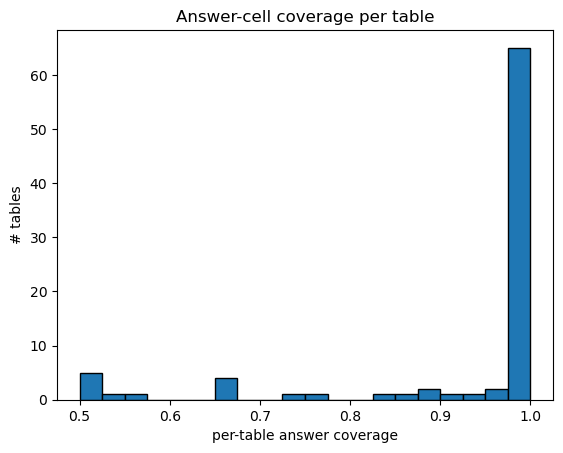

In [5]:
# Optional tabular view + histogram (requires pandas / matplotlib)
try:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df.sort_values("coverage", na_position="first").head(15))
    print("\nper-table coverage describe():")
    display(df["coverage"].describe())
    try:
        import matplotlib.pyplot as plt
        ax = df["coverage"].dropna().plot(kind="hist", bins=20, edgecolor="black")
        ax.set_xlabel("per-table answer coverage"); ax.set_ylabel("# tables")
        ax.set_title("Answer-cell coverage per table"); plt.show()
    except Exception as e:
        print("(matplotlib unavailable:", e, ")")
except Exception as e:
    print("(pandas unavailable:", e, ")")

## 4 · Diagnosis — empty tables & uncovered answers

The uncovered answers fall into a few buckets:
- **empty SMP** — the `.txt` walk file has no lines
- **answer-is-header** — the answer cell has `table-header == "Yes"`, so by the
  parsing rule it is a *pivot*, never a *node*
- **pass-through value** — a value cell never sitting at a change of direction

In [6]:
empty_tables = []
uncovered = []  # (tid, ans_id, is_header, content)

for tid in IDS:
    ups_t, _ = smp.generate_upaths_for_table(SMP_DIR / f"{tid}.txt", JSON_DIR / f"{tid}.json")
    if not ups_t:
        empty_tables.append(tid)
    n_ids = {u.node_id for u in ups_t}
    cells, _ = smp.load_table_cells(JSON_DIR / f"{tid}.json")
    qs = json.loads((QA_DIR / f"{tid}.json").read_text(encoding="utf-8")).get("questions", [])
    for q in qs:
        try:
            a = int(q.get("answer_cell_id"))
        except (TypeError, ValueError):
            continue
        if a not in n_ids:
            c = cells.get(a, {})
            uncovered.append((tid, a, c.get("header"), c.get("content", "")))

buckets = {"empty_smp": 0, "answer_is_header": 0, "pass_through_value": 0}
empty_set = set(empty_tables)
for tid, a, is_h, _ in uncovered:
    if tid in empty_set:
        buckets["empty_smp"] += 1
    elif is_h:
        buckets["answer_is_header"] += 1
    else:
        buckets["pass_through_value"] += 1

print(f"empty SMP tables ({len(empty_tables)}):")
for t in empty_tables:
    print("   ", t)
print(f"\nuncovered answers total: {len(uncovered)}")
for k, v in buckets.items():
    print(f"   {k:<20}: {v}")

print("\nsample uncovered answers:")
for tid, a, is_h, content in uncovered[:12]:
    print(f"   {tid}  id={a:>3} header={is_h}  {content[:60]!r}")

empty SMP tables (3):
    5767b8cd-d14f-4c95-ab03-676959a846ad
    a8a20019-6b60-409d-bce4-967b0cd026a4
    b27d69f5-fd16-4463-8ffb-53074cf7b006

uncovered answers total: 37
   empty_smp           : 0
   answer_is_header    : 26
   pass_through_value  : 11

sample uncovered answers:
   0b6979f0-3ffe-431c-83c0-4b3ef6010d31  id=  6 header=False  '159'
   165a6562-682b-4390-863f-3d4379b0f068  id=  2 header=True  '3M™ Scotch-Weld Metal Bonder Acrylic Adhesive  DP8407NS Grey'
   2a851491-48c6-4a93-bbec-af1132f4a611  id= 14 header=False  '1.17'
   32c69474-c2e1-43b6-acd4-4e87b8cf0c52  id=  4 header=True  'Recommended temperature'
   40b12b70-e85f-404f-93fb-9eb0b6bd2135  id=  0 header=True  'Heat cure'
   5160d529-33af-4f1d-b556-6cce6dca0202  id=  0 header=True  'Peel Strength  Roller peel specimens were made according to '
   634077ab-cf32-464b-a023-ddd67aab4b2a  id=  2 header=True  '-55 +/-2'
   634077ab-cf32-464b-a023-ddd67aab4b2a  id=  4 header=True  '23 +/- 2'
   634077ab-cf32-464b-a023-

## 5 · Dataset assembly

Build the `TableEmbedJePADataset` with `precompute=False` (no embedding calls) to
verify record construction, flat-sample generation and unique-table indexing.

> Requires `pytorch_lightning` (same env used for training). If it is missing the
> cell reports that and skips.

In [3]:
try:
    import importlib, dataset as ds_mod
    importlib.reload(ds_mod)
    ds = ds_mod.TableEmbedJePADataset(data_dir=DATA_DIR, precompute=False)
    print("\nrecords              :", len(ds.records))
    print("flat U-path samples  :", len(ds._samples))
    print("unique-table samples :", len(ds._unique_table_train_idxs))
    print("example record       :", ds.records[0])
    r0, u0 = ds._samples[0]
    print("example sample       :", u0.col_header_a, "|", u0.cell_value, "|", u0.col_header_b,
          "(node_id=", u0.node_id, ")")

    # answer coverage as seen by the dataset
    by_tid = {}
    for r, u in ds._samples:
        by_tid.setdefault(ds.records[r]["table_id"], set()).add(u.node_id)
    miss = sum(1 for rec in ds.records
               if rec["answer_cell_id"] >= 0
               and rec["answer_cell_id"] not in by_tid.get(rec["table_id"], set()))
    print(f"records w/o matching U-path node: {miss}/{len(ds.records)}")
except ModuleNotFoundError as e:
    print("[skip] dataset assembly needs an extra package:", e)
except Exception as e:
    print("[error]", type(e).__name__, e)

[dataset][discover] 89 tables under ReleasedTableDatasetAdhesive
[dataset][load] 816 question-records from 86 tables
[dataset][smp_gen] 15248 U-path samples from 816 records
[dataset][unique_tables] 86 unique tables → 1109 training samples (of 15248 total)

records              : 816
flat U-path samples  : 15248
unique-table samples : 1109
example record       : {'table_id': '03323a0f-1ea7-4e29-b75f-9cf63db9e940', 'id': '03323a0f-1ea7-4e29-b75f-9cf63db9e940#0', 'question': 'What is the dielectric strength?', 'answer': '400', 'answer_cell_id': 3, 'row_header': 'Dielectric strength (Ohm)', 'column_header': 'Test values'}
example sample       : Dielectric constant at 50H2/1kHz/10kHz | IEC 60250 | Test methods (node_id= 16 )
records w/o matching U-path node: 37/816


## Summary

Re-run the cell below any time to get a one-line health check of the parser.

In [8]:
print(f"tables={len(IDS)}  U-paths={tot_up}  questions={tot_q}  "
      f"coverage={100*tot_c/max(tot_q,1):.1f}%  empty_smp={empty}")

tables=89  U-paths=1048  questions=816  coverage=95.5%  empty_smp=3


## Test 6 — model forward/backward on the variable-length, role-masked batch

Builds a tiny precomputed dataset for a single table, collates it with the new
`jepa_collate_fn` (right-padded sequences + `smp_role` / `smp_pad_mask`), then
runs `TableEmbedJePA.forward` + `backward` and the eval node-encoder. Verifies
the node role mask marks exactly one slot per U-path inside the valid region and
that all four losses are finite.


In [4]:
import importlib, torch
import torch.nn.functional as F

try:
    import smp as smp_mod, dataset as ds_mod, config as cfg_mod, model as model_mod
    for _m in (smp_mod, ds_mod, cfg_mod, model_mod):
        importlib.reload(_m)
    from dataset import jepa_collate_fn
    from config import TableEmbedJePAConfig
    from model import TableEmbedJePA

    # tiny precomputed dataset for a single table (local MiniLM encoder)
    ds_small = ds_mod.TableEmbedJePADataset(
        data_dir=DATA_DIR, model_type="huggingface",
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        filter_table_id=TID, precompute=True, cache_embeddings=False,
        embed_batch_size=64,
    )
    d, N, Lmax = ds_small.embed_dim, len(ds_small), ds_small._seq_idx.shape[1]
    print(f"embed_dim={d}  samples={N}  Lmax={Lmax}")

    batch = jepa_collate_fn([ds_small[i] for i in range(N)])
    for k, v in batch.items():
        if torch.is_tensor(v):
            print(f"  {k:16s} {tuple(v.shape)}")

    # invariants: exactly one node per row, node inside the valid (non-pad) region
    assert torch.allclose(batch["smp_role"].sum(1),     torch.ones(N)), "one node / fwd row"
    assert torch.allclose(batch["smp_bar_role"].sum(1), torch.ones(N)), "one node / bar row"
    assert (batch["smp_role"] * (1 - batch["smp_pad_mask"])).sum() == 0, "node inside valid region"
    print("role / pad-mask invariants OK")

    # tiny model → forward → backward
    mcfg = TableEmbedJePAConfig(
        hidden_size=d, num_hidden_layers=1, num_attention_heads=6,
        intermediate_size=d * 4, embedding_dim=d, tempeture=0.07, beta=0.5)
    mdl = TableEmbedJePA(mcfg, ablate_proj=True).train()
    out = mdl(
        smp_embeds=batch["smp_embeds"], smp_bar_embeds=batch["smp_bar_embeds"],
        smp_role=batch["smp_role"], smp_bar_role=batch["smp_bar_role"],
        smp_pad_mask=batch["smp_pad_mask"],
        query_embeds=batch["query_embeds"], query_bar_embeds=batch["query_bar_embeds"])
    print("losses  total=%.4f jepa=%.4f jepa_bar=%.4f local=%.4f global=%.4f" % (
        out.loss.item(), out.jepa_loss.item(), out.jepa_bar_loss.item(),
        out.local_loss.item(), out.global_loss.item()))
    assert torch.isfinite(out.loss), "loss must be finite"
    out.loss.backward()
    print("backward OK — cls_token grad:", mdl.cls_token.grad is not None)

    # eval node-encoder (mirrors train._encode_nodes) on the padded table
    def _encode_nodes(model, seq_raw, role, pad_mask):
        n, NEG = seq_raw.shape[0], -1e9
        with torch.no_grad():
            proj = model.input_projection(seq_raw)
            cls  = model.input_projection(model.cls_token).expand(n, -1, -1)
            inp  = torch.cat([cls, proj], dim=1)
            pad_full  = torch.cat([torch.ones(n, 1),  pad_mask], dim=1)
            role_full = torch.cat([torch.zeros(n, 1), role],     dim=1)
            attn = (1.0 - pad_full)[:, None, None, :] * NEG
            enc, _, _ = model.transformer_encoder(inp, mask=attn)
            r = role_full.unsqueeze(-1)
            node = (enc * r).sum(1) / r.sum(1).clamp_min(1e-6)
            return F.normalize(node, dim=-1)

    pad = (torch.arange(Lmax).unsqueeze(0) < ds_small._seq_len.unsqueeze(1)).float()
    na = _encode_nodes(mdl.eval(), ds_small._embed_cache[ds_small._seq_idx],
                       ds_small._role, pad)
    print("node embeds:", tuple(na.shape), " mean|.|=", round(na.norm(dim=1).mean().item(), 4))
    print("\nTest 6 (forward + backward + encode) PASSED")
except ModuleNotFoundError as e:
    print("[skip] model smoke test needs an extra package:", e)
except Exception as e:
    import traceback; traceback.print_exc()
    print("[error]", type(e).__name__, e)


[dataset][discover] 1 tables under ReleasedTableDatasetAdhesive [table_id=03323a0f-1ea7-4e29-b75f-9cf63db9e940]
[dataset][load] 6 question-records from 1 tables
[dataset][smp_gen] 60 U-path samples from 6 records
[dataset][unique_tables] 1 unique tables → 10 training samples (of 60 total)
[dataset][cache] looking for cache files with prefix adhesive_03323a0f-1ea7-4e29-b75f-9cf63db9e940_sentence-transformers-all-MiniLM-L6-v2_seq_dim_ …
[dataset][embed] 35 unique texts (batch_size=64)...
[dataset][embed] 35/35  (100.0%)
[dataset][embed_questions] 6 question embeddings...
[dataset][embed] 6/6  (100.0%)
[dataset][build_index] done  embed_dim=384
embed_dim=384  samples=60  Lmax=3
  smp_embeds       (60, 3, 384)
  smp_role         (60, 3)
  smp_pad_mask     (60, 3)
  smp_bar_embeds   (60, 3, 384)
  smp_bar_role     (60, 3)
  query_embeds     (60, 1, 384)
  query_bar_embeds (60, 1, 384)
  question_embeds  (60, 384)
  record_indices   (60,)
role / pad-mask invariants OK
losses  total=8.6116 je

In [5]:
# Walk-length distribution over the full dataset — proves nested headers give L>3
from collections import Counter
len_hist = Counter(u.seq_len for _, u in ds._samples)
nested   = sum(v for k, v in len_hist.items() if k > 3)
print("walk-length histogram (seq_len -> count):")
for L in sorted(len_hist):
    bar = "#" * min(60, len_hist[L] * 60 // max(len_hist.values()))
    print(f"  L={L:>2}: {len_hist[L]:>6}  {bar}")
print(f"\nnested-header U-paths (L>3): {nested}/{len(ds._samples)} "
      f"({100*nested/len(ds._samples):.1f}%)   max walk length = {max(len_hist)}")

# show a couple of nested examples (pivot_a is a composition of >1 header)
shown = 0
for _, u in ds._samples:
    if len(u.a_header_texts) > 1 or len(u.b_header_texts) > 1:
        print(f"  a={u.a_header_texts}  node={u.cell_value!r}  b={u.b_header_texts}")
        shown += 1
        if shown >= 3:
            break


walk-length histogram (seq_len -> count):
  L= 2:    126  
  L= 3:  10416  ############################################################
  L= 4:   3047  #################
  L= 5:    736  ####
  L= 6:    188  #
  L= 7:    106  
  L= 8:    101  
  L= 9:     96  
  L=10:     96  
  L=11:     96  
  L=12:     96  
  L=13:     72  
  L=14:     24  
  L=15:     24  
  L=16:     12  
  L=17:     12  

nested-header U-paths (L>3): 4706/15248 (30.9%)   max walk length = 17
  a=[]  node='O°C to +10°C'  b=['Recommended temperature', 'Storage']
  a=['Min storage temperature']  node='+10°C'  b=['Recommended temperature', 'Storage']
  a=[]  node='O°C to +10°C'  b=['Recommended temperature', 'Storage']


## Test 7 — SMP as processed by the Dataset + DataLoader

Runs one table through a real `DataLoader` + `jepa_collate_fn` (exactly the training
path) and reconstructs each padded SMP row from `_seq_idx` so we can see, per sample:

- the **variable walk length** (`smp_len`) vs. the padded tensor width,
- the **role mask** (`smp_role`, 1 = node) and **pad mask** (`smp_pad_mask`, 1 = valid),
- the actual header / node / pad **text** occupying every slot.

Invariants asserted: padded slots hold zero vectors, exactly one node per row (both
orientations), and the node always lies inside the valid (non-pad) region.


In [7]:
# Assess the SMPs exactly as the Dataset + DataLoader hand them to the model.
import importlib, torch
from torch.utils.data import DataLoader

try:
    import smp as smp_mod, dataset as ds_mod
    importlib.reload(smp_mod); importlib.reload(ds_mod)
    from dataset import jepa_collate_fn

    # Pick a table that actually exercises variable-length walks (nested headers),
    # so per-batch padding is visible; fall back to TID if none is longer.
    CHECK_TID, best_L = TID, 0
    for _t in IDS:
        try:
            _ups, _ = smp_mod.generate_upaths_for_table(SMP_DIR / f"{_t}.txt", JSON_DIR / f"{_t}.json")
        except Exception:
            continue
        _m = max((u.seq_len for u in _ups), default=0)
        if _m > best_L:
            best_L, CHECK_TID = _m, _t
    print(f"selected table {CHECK_TID}  (max walk length = {best_L})")

    # Precomputed dataset for that table (local MiniLM encoder), no disk cache.
    ds_check = ds_mod.TableEmbedJePADataset(
        data_dir=DATA_DIR, model_type="huggingface",
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        filter_table_id=CHECK_TID, precompute=True, cache_embeddings=False,
        embed_batch_size=64,
    )
    N = len(ds_check)
    loader = DataLoader(ds_check, batch_size=N, shuffle=False, collate_fn=jepa_collate_fn)

    lens = ds_check._seq_len.tolist()
    print(f"samples={N}  walk lengths seen={sorted(set(lens))}  "
          f"min={min(lens)} max={max(lens)}  dataset Lmax={ds_check._seq_idx.shape[1]}")

    # idx -> text inverse map to reconstruct what each slot holds
    idx2txt = {i: t for t, i in ds_check._text_to_idx.items()}
    def slot(i):
        return "<PAD>" if int(i) == ds_check._pad_idx else idx2txt.get(int(i), "?")

    batch = next(iter(loader))
    print("\nbatch tensor shapes (as fed to the model):")
    for kk, vv in batch.items():
        if torch.is_tensor(vv):
            print(f"  {kk:16s} {tuple(vv.shape)}")

    Lb = batch["smp_embeds"].shape[1]
    # show a spread of rows: shortest + longest walks, so padding is visible
    order = sorted(range(N), key=lambda i: lens[i])
    show = order[:3] + order[-4:] if N > 7 else list(range(N))
    print(f"\nreconstructed SMP rows (padded to L={Lb})   tag: h=header  N=node  P=pad")
    for bi in show:                                    # shuffle=False → row bi == sample bi
        idx_row = ds_check._seq_idx[bi][:Lb]
        pm = batch["smp_pad_mask"][bi].int().tolist()
        rl = batch["smp_role"][bi].int().tolist()
        tag = lambda k: "N" if rl[k] else ("P" if pm[k] == 0 else "h")
        seq = "  ".join(f"{tag(k)}:{slot(idx_row[k])[:14]!r}" for k in range(Lb))
        print(f"  row {bi:>2} len={int(sum(pm)):>2} pad={Lb-int(sum(pm))} | {seq}")

    # ── invariants that make padding harmless during training ──────────────
    emb, pm, role = batch["smp_embeds"], batch["smp_pad_mask"], batch["smp_role"]
    pad_pos = (pm == 0)
    assert torch.allclose(emb[pad_pos], torch.zeros_like(emb[pad_pos])), \
        "padded slots must hold zero embedding vectors"
    assert torch.allclose(role.sum(1), torch.ones(role.shape[0])), \
        "exactly one node per forward row"
    assert torch.allclose(batch["smp_bar_role"].sum(1), torch.ones(role.shape[0])), \
        "exactly one node per reversed row"
    assert (role * (1 - pm)).sum() == 0, \
        "node slot must lie inside the valid (non-pad) region"
    print(f"\ntotal padded slots in batch: {int((pm == 0).sum())}  "
          f"(of {pm.numel()} = {N}×{Lb})")
    print("invariants OK: pad slots zero, one node/row (fwd+bar), node inside valid region")
    print("Test 7 (dataset + dataloader SMP processing) PASSED")
except ModuleNotFoundError as e:
    print("[skip] needs an extra package:", e)
except Exception as e:
    import traceback; traceback.print_exc()
    print("[error]", type(e).__name__, e)


selected table fbfc9178-cedc-40bc-99bb-3c440d041d7e  (max walk length = 17)
[dataset][discover] 1 tables under ReleasedTableDatasetAdhesive [table_id=fbfc9178-cedc-40bc-99bb-3c440d041d7e]
[dataset][load] 12 question-records from 1 tables
[dataset][smp_dedup] kept 24 unique-text SMPs (removed 264 text-duplicates)
[dataset][smp_gen] 24 U-path samples from 12 records
[dataset][unique_tables] 1 unique tables → 24 training samples (of 24 total)
[dataset][cache] looking for cache files with prefix adhesive_fbfc9178-cedc-40bc-99bb-3c440d041d7e_sentence-transformers-all-MiniLM-L6-v2_useq_dim_ …
[dataset][embed] 73 unique texts (batch_size=64)...
[dataset][embed] 73/73  (100.0%)
[dataset][embed_questions] 12 question embeddings...
[dataset][embed] 12/12  (100.0%)
[dataset][build_index] done  embed_dim=384
samples=24  walk lengths seen=[4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]  min=4 max=17  dataset Lmax=17

batch tensor shapes (as fed to the model):
  smp_embeds       (24, 17, 384)
  smp_

## Test 8 — JSON-only U-path generation (no SMP walk file)

`smp.generate_upaths_from_json` builds U-paths from the table JSON **structure alone**:

1. **Detect the table type** from its first column — if the left-most column cells are
   headers it is *row-column oriented* (matrix); otherwise it is *column-oriented*.
2. For every value cell, gather nested **column headers** (ascend `up` through data
   cells to the header band) and, for matrix tables, nested **row headers** (go `left`).
3. Emit one path per value cell:
   - column-oriented → **U** : `colH… | node | …colH` (headers mirrored)
   - row-column      → **L-reversed** : `rowH… | node | colH…`

This cell shows the detected orientation + reconstructed paths for one table, then
compares dataset-wide answer coverage against the walk-file method.


In [8]:
import importlib
import smp as smp_mod
importlib.reload(smp_mod)

# ── (a) one table: show detected orientation + reconstructed JSON-only paths ──
row_col = smp_mod._is_row_column_oriented(smp_mod.load_table_graph(JSON_DIR / f"{TID}.json")[0])
ups_json, _ = smp_mod.generate_upaths_from_json(JSON_DIR / f"{TID}.json")
print(f"table {TID}")
print(f"orientation : {'row-column (L-reversed)' if row_col else 'column-oriented (U)'}")
print(f"JSON U-paths: {len(ups_json)}")
for u in ups_json[:8]:
    print(f"  node_id={u.node_id:>3} | a={u.a_header_texts} | node={u.cell_value!r} | b={u.b_header_texts}")

# ── (b) dataset-wide coverage: JSON-only vs walk-file method ──────────────────
def _coverage(gen):
    tot = cov = ups_tot = 0
    orient = {"row_column": 0, "column": 0}
    for tid in IDS:
        try:
            ups_t, _ = gen(tid)
        except Exception:
            continue
        ups_tot += len(ups_t)
        graph, _ = smp_mod.load_table_graph(JSON_DIR / f"{tid}.json")
        orient["row_column" if smp_mod._is_row_column_oriented(graph) else "column"] += 1
        n_ids = {u.node_id for u in ups_t}
        qs = json.loads((QA_DIR / f"{tid}.json").read_text(encoding="utf-8")).get("questions", [])
        for q in qs:
            try:
                a = int(q.get("answer_cell_id"))
            except (TypeError, ValueError):
                continue
            tot += 1
            cov += (a in n_ids)
    return ups_tot, cov, tot, orient

json_up, json_c, json_q, orient = _coverage(
    lambda t: smp_mod.generate_upaths_from_json(JSON_DIR / f"{t}.json"))
walk_up, walk_c, walk_q, _ = _coverage(
    lambda t: smp_mod.generate_upaths_for_table(SMP_DIR / f"{t}.txt", JSON_DIR / f"{t}.json"))

print(f"\norientation split : row-column={orient['row_column']}  column-oriented={orient['column']}")
print(f"JSON-only : U-paths={json_up:>5}  answer coverage={json_c}/{json_q} "
      f"({100*json_c/max(json_q,1):.1f}%)")
print(f"walk-file : U-paths={walk_up:>5}  answer coverage={walk_c}/{walk_q} "
      f"({100*walk_c/max(walk_q,1):.1f}%)")
print("\nTest 8 (JSON-only U-path generation) done")


table 03323a0f-1ea7-4e29-b75f-9cf63db9e940
orientation : row-column (L-reversed)
JSON U-paths: 10
  node_id=  3 | a=['Dielectric strength (Volt/mil)'] | node='400' | b=['Test values']
  node_id=  5 | a=['Surface resistivity (Ohm)'] | node='1.2 E+16' | b=['Test values']
  node_id=  7 | a=['Volume resistivity (Ohm'] | node='7.1 E+14' | b=['Test values']
  node_id=  9 | a=['Dielectric constant at 50H2/1kHz/10kHz'] | node='3.4/ 3.2/ 3.2' | b=['Test values']
  node_id= 11 | a=['Loss tangent, % at 50Hz/1kHz/10kHz'] | node='1.7/ 1.8/2.6' | b=['Test values']
  node_id= 13 | a=['Dielectric strength (Volt/mil)'] | node='ASTM D-149' | b=['Test methods']
  node_id= 14 | a=['Surface resistivity (Ohm)'] | node='IEC 60093' | b=['Test methods']
  node_id= 15 | a=['Volume resistivity (Ohm'] | node='IEC 60093' | b=['Test methods']

orientation split : row-column=83  column-oriented=6
JSON-only : U-paths=  935  answer coverage=809/816 (99.1%)
walk-file : U-paths= 1122  answer coverage=794/816 (97.3%)

Te

In [11]:
# ── (c) nested-header samples, split by path type ────────────────────────────
# A nested header stacks >1 header on a side, so the pivot composes them all.
#   • U-path  (column-oriented, mirrored) : seq = colH… | node | …colH  → L is ODD
#       nested ⇔ ≥2 headers per side ⇒ L ≥ 5  (i.e. L > 4)
#   • L-rev   (row-column matrix)         : seq = rowH… | node | colH…
#       nested ⇔ ≥3 headers total        ⇒ L ≥ 4  (i.e. L > 3)
from collections import Counter

u_hist, l_hist = Counter(), Counter()          # seq_len -> count, per path type
u_nested, l_nested = [], []                    # (tid, UPath) meeting the threshold

for tid in IDS:
    graph, _ = smp_mod.load_table_graph(JSON_DIR / f"{tid}.json")
    is_rowcol = smp_mod._is_row_column_oriented(graph)      # True → L-reversed
    ups_t, _ = smp_mod.generate_upaths_from_json(JSON_DIR / f"{tid}.json")
    for u in ups_t:
        if is_rowcol:
            l_hist[u.seq_len] += 1
            if u.seq_len > 3:                  # L-reversed nested: >3
                l_nested.append((tid, u))
        else:
            u_hist[u.seq_len] += 1
            if u.seq_len > 4:                  # U-path nested: >4
                u_nested.append((tid, u))


def _report(title, hist, nested, thr):
    tot = sum(hist.values())
    hit = sum(v for k, v in hist.items() if k > thr)
    print(f"\n=== {title} ===")
    print(f"seq_len histogram: " + "  ".join(f"L={k}:{hist[k]}" for k in sorted(hist)))
    print(f"nested (L>{thr}): {hit}/{tot} ({100*hit/max(tot,1):.1f}%)")
    # SMP shown exactly as Test 8:  node_id | a=[…] | node | b=[…]
    for tid, u in sorted(nested, key=lambda tu: tu[1].seq_len, reverse=True)[:4]:
        print(f"  table {tid[:8]}  node_id={u.node_id:>3} | a={u.a_header_texts} "
              f"| node={u.cell_value!r} | b={u.b_header_texts}")


_report("U-path (column-oriented, mirrored) — nested L>4", u_hist, u_nested, 4)
_report("L-reversed (row-column matrix) — nested L>3",     l_hist, l_nested, 3)

print("\nnested-header sample check done")



=== U-path (column-oriented, mirrored) — nested L>4 ===
seq_len histogram: L=3:2  L=5:6
nested (L>4): 6/8 (75.0%)
  table 634077ab  node_id=  2 | a=['Overlap Shear Strength  Overlap shear specimens were made according to ISO 4587 using 1.6 mm thick clad aluminium 2024 T3 Surface prepared by the optimised FPL etch method.', 'Test Conditions (°C)'] | node='-55 +/-2' | b=['Test Conditions (°C)', 'Overlap Shear Strength  Overlap shear specimens were made according to ISO 4587 using 1.6 mm thick clad aluminium 2024 T3 Surface prepared by the optimised FPL etch method.']
  table 634077ab  node_id=  3 | a=['Overlap Shear Strength  Overlap shear specimens were made according to ISO 4587 using 1.6 mm thick clad aluminium 2024 T3 Surface prepared by the optimised FPL etch method.', 'Results (MPa)'] | node='28' | b=['Results (MPa)', 'Overlap Shear Strength  Overlap shear specimens were made according to ISO 4587 using 1.6 mm thick clad aluminium 2024 T3 Surface prepared by the optimised FPL etch

## Test 9 — JSON-only U-paths through the Dataset + DataLoader (training path)

`TableEmbedJePADataset` now accepts `upath_source="json"`, which builds every
U-path from the table JSON structure (via `generate_upaths_from_json`) instead of
the pre-computed SMP walk files. This cell builds the dataset both ways for one
table, collates each with `jepa_collate_fn`, and confirms the JSON source feeds
the model the same tensor contract (variable-length, role-masked, padded).


In [12]:
# Build the dataset with upath_source="json" and run it through the training path.
import importlib, torch
from torch.utils.data import DataLoader

try:
    import dataset as ds_mod
    importlib.reload(ds_mod)
    from dataset import jepa_collate_fn

    # Use a table with nested headers so JSON-only paths are non-trivial.
    JTID = "634077ab" if any(t.startswith("634077ab") for t in IDS) else CHECK_TID
    JTID = next((t for t in IDS if t.startswith(JTID)), CHECK_TID)

    def _build(source):
        d = ds_mod.TableEmbedJePADataset(
            data_dir=DATA_DIR, model_type="huggingface",
            model_name="sentence-transformers/all-MiniLM-L6-v2",
            filter_table_id=JTID, precompute=True, cache_embeddings=False,
            embed_batch_size=64, upath_source=source)
        return d

    ds_json = _build("json")
    ds_walk = _build("walk")
    print(f"\ntable {JTID}")
    print(f"  json-source : samples={len(ds_json):>3}  Lmax={ds_json._seq_idx.shape[1]}  "
          f"lens={sorted(set(ds_json._seq_len.tolist()))}")
    print(f"  walk-source : samples={len(ds_walk):>3}  Lmax={ds_walk._seq_idx.shape[1]}  "
          f"lens={sorted(set(ds_walk._seq_len.tolist()))}")

    # Run the JSON dataset through a real DataLoader + collate (the training path).
    N = len(ds_json)
    loader = DataLoader(ds_json, batch_size=N, shuffle=False, collate_fn=jepa_collate_fn)
    batch = next(iter(loader))
    print("\njson-source batch tensor shapes (as fed to the model):")
    for kk, vv in batch.items():
        if torch.is_tensor(vv):
            print(f"  {kk:16s} {tuple(vv.shape)}")

    # Same invariants Test 7 asserts — proves the JSON source honours the contract.
    emb, pm, role = batch["smp_embeds"], batch["smp_pad_mask"], batch["smp_role"]
    assert torch.allclose(emb[pm == 0], torch.zeros_like(emb[pm == 0])), "pad slots zero"
    assert torch.allclose(role.sum(1), torch.ones(role.shape[0])), "one node / fwd row"
    assert torch.allclose(batch["smp_bar_role"].sum(1), torch.ones(role.shape[0])), "one node / bar row"
    assert (role * (1 - pm)).sum() == 0, "node inside valid region"
    print("\ninvariants OK — JSON-only U-paths flow through the DataLoader unchanged")
    print("Test 9 (JSON-only dataset + dataloader) PASSED")
except ModuleNotFoundError as e:
    print("[skip] needs an extra package:", e)
except Exception as e:
    import traceback; traceback.print_exc()
    print("[error]", type(e).__name__, e)


[dataset][discover] 1 tables under ReleasedTableDatasetAdhesive [source=json] [table_id=634077ab-cf32-464b-a023-ddd67aab4b2a]
[dataset][load] 6 question-records from 1 tables
[dataset][smp_dedup] kept 6 unique-text SMPs (removed 30 text-duplicates)
[dataset][smp_gen] 6 U-path samples from 6 records
[dataset][unique_tables] 1 unique tables → 6 training samples (of 6 total)
[dataset][cache] looking for cache files with prefix adhesive_634077ab-cf32-464b-a023-ddd67aab4b2a_sentence-transformers-all-MiniLM-L6-v2_json_useq_dim_ …
[dataset][embed] 13 unique texts (batch_size=64)...
[dataset][embed] 13/13  (100.0%)
[dataset][embed_questions] 6 question embeddings...
[dataset][embed] 6/6  (100.0%)
[dataset][build_index] done  embed_dim=384
[dataset][discover] 1 tables under ReleasedTableDatasetAdhesive [source=walk] [table_id=634077ab-cf32-464b-a023-ddd67aab4b2a]
[dataset][load] 6 question-records from 1 tables
[dataset][smp_dedup] kept 6 unique-text SMPs (removed 30 text-duplicates)
[dataset][

## Test 10 — HIT threshold ($\alpha_0$) from human labels

Reproduce Fig. 4: for every question that carries a `binary_vector` whose length
matches `question.split()`, embed each token, score it by cosine similarity to the
full-question embedding, min-max normalise per question, then fit a Gaussian to the
`L=0` (non-HIT) and `L=1` (HIT) score sets. The threshold $\alpha_0$ is the density
intersection between the two means. The figure is saved as
`results/hit_threshold_<model-slug>.png`.


[hit_thr] questions with binary_vector: 625/816  |  usable (split matches labels): 478
[hit_thr] threshold=0.2894  (embed_dim=768)  →  C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL_Adhesive\results\hit_threshold_sentence-transformers-all-mpnet-base-v2.png
{
  "model_name": "sentence-transformers/all-mpnet-base-v2",
  "model_slug": "sentence-transformers-all-mpnet-base-v2",
  "embed_dim": 768,
  "threshold": 0.2894,
  "L0": {
    "mean": 0.098,
    "std": 0.0877,
    "n": 2054
  },
  "L1": {
    "mean": 0.6983,
    "std": 0.2506,
    "n": 2404
  },
  "P(L=0|a<t)": 0.9855,
  "P(L=0|a>t)": 0.0145,
  "P(L=1|a<t)": 0.0514,
  "P(L=1|a>t)": 0.9486,
  "n_questions_binary_vector": 625,
  "n_questions_total": 816,
  "n_questions_used": 478,
  "figure_png": "C:\\Users\\wtchuitc\\Documents\\GitHub\\UTUEL\\TRL_Adhesive\\results\\hit_threshold_sentence-transformers-all-mpnet-base-v2.png",
  "figure_pdf": "C:\\Users\\wtchuitc\\Documents\\GitHub\\UTUEL\\TRL_Adhesive\\results\\hit_threshold_sentence-tra

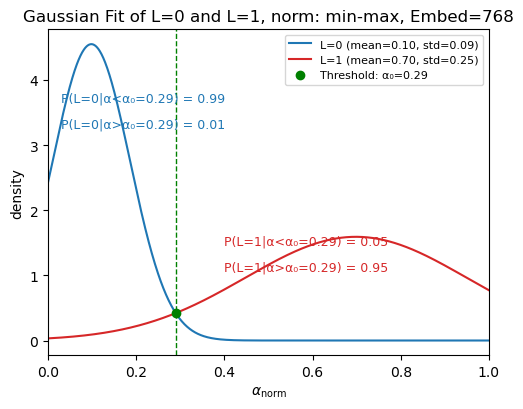

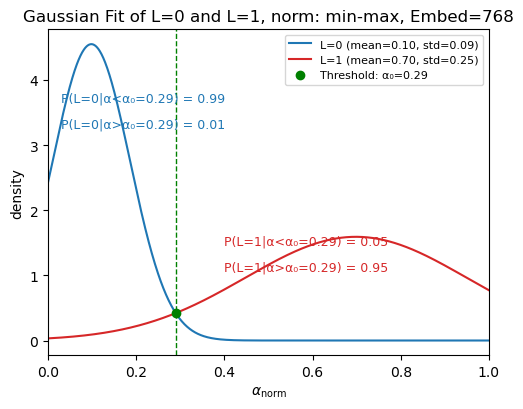

In [14]:
from compute_hit_threshold import compute_hit_threshold

# MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MODEL_NAME =  "sentence-transformers/all-mpnet-base-v2"  # better than MiniLM
result, fig = compute_hit_threshold(
    data_dir=DATA_DIR,
    model_type="huggingface",
    model_name=MODEL_NAME,
)

import json
print(json.dumps(result, indent=2))
print(f"\nSet config.yaml -> hit.thresholds['{MODEL_NAME}']: {result['threshold']}")
fig  # inline display


## Test 11 — query embedding shift (RAW vs SW vs HIT)

Quantify the *content-based query distribution shift* across the three query
variants used at eval time: **RAW** (original question), **SW** (stop-word
filtered) and **HIT** (high-informative-token filtered). For each of the ~816
questions the cosine similarity between its RAW embedding and its SW / HIT
counterpart is computed, a Gaussian is fitted per set (left panel), and a shared
2-D PCA shows all three spaces with one tracked query circled in each (right
panel). Saved as `results/query_shift_<model-slug>.png`.


[qshift] questions: 816  |  HIT threshold: 0.2900  |  model: sentence-transformers/all-mpnet-base-v2
[qshift] RAW->SW μ=0.909  RAW->HIT μ=0.898  →  C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL_Adhesive\results\query_shift_sentence-transformers-all-mpnet-base-v2.png
{
  "model_name": "sentence-transformers/all-mpnet-base-v2",
  "model_slug": "sentence-transformers-all-mpnet-base-v2",
  "embed_dim": 768,
  "hit_threshold": 0.29,
  "n_questions": 816,
  "tracked_index": 0,
  "raw_to_sw": {
    "mean": 0.9092,
    "std": 0.0752,
    "shift": 0.0908
  },
  "raw_to_hit": {
    "mean": 0.8976,
    "std": 0.076,
    "shift": 0.1024
  },
  "figure_png": "C:\\Users\\wtchuitc\\Documents\\GitHub\\UTUEL\\TRL_Adhesive\\results\\query_shift_sentence-transformers-all-mpnet-base-v2.png",
  "figure_pdf": "C:\\Users\\wtchuitc\\Documents\\GitHub\\UTUEL\\TRL_Adhesive\\results\\query_shift_sentence-transformers-all-mpnet-base-v2.pdf"
}


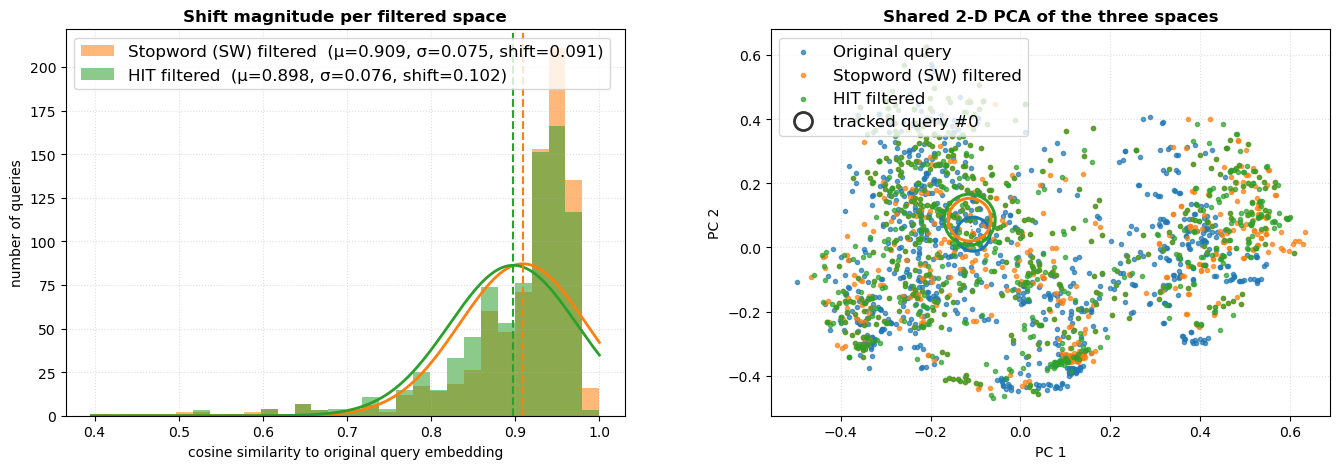

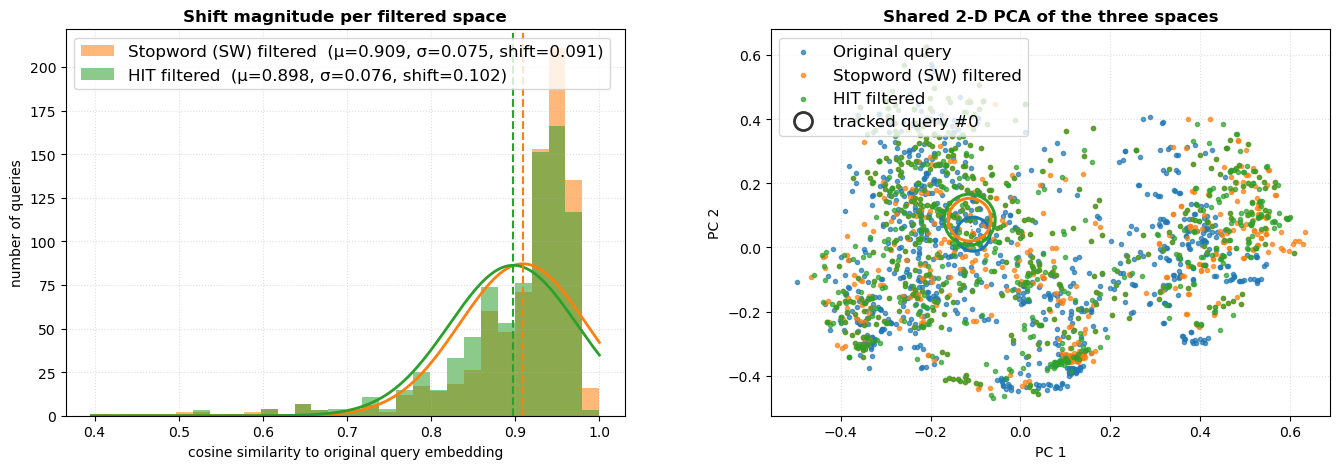

In [2]:
%reload_ext autoreload
%autoreload 2
from query_shift_plot import compute_query_shift
from pathlib import Path
MODEL_NAME =  "sentence-transformers/all-mpnet-base-v2"  # better than MiniLM
# MODEL_NAME =  "sentence-transformers/all-MiniLM-L6-v2"  # smaller, faster, slightly worse
DATA_DIR = Path(r"D:\TABLE_DATASET\DATASET_ABOUT_ADHESIVE\ReleasedTableDatasetAdhesive")

# Same model as the HIT-threshold cell; HIT threshold is read from config.yaml
# (hit.thresholds[model] -> hit.default_threshold) unless hit_threshold=... is set.
result, fig = compute_query_shift(
    data_dir=DATA_DIR,
    model_type="huggingface",
    model_name=MODEL_NAME,
    arrays=("questions",),   # the 816 training/eval questions
    track_index=0,           # query circled in each PCA space
)

import json
print(json.dumps(result, indent=2))
fig  # inline display


## Run training

`train.py` is a Hydra app, so parameters are passed as `key=value` overrides.
Edit `TRAIN_PARAMS` below, then run the next cell — it launches `train.py` in a
fresh subprocess so the current code on disk is always used (no stale kernel
modules, no Hydra re-init issues).

In [2]:
# Hydra overrides for train.py (edit as needed) -> passed as a single {param} argument
TRAIN_PARAMS = " ".join([
    "embedder.model_type=huggingface",
    "embedder.model_name=sentence-transformers/all-mpnet-base-v2",
    "embedder.embed_dim=null",          # null = no cap, use native embedding dim
    "model.hidden_size=768",
    "training.mode=global",             # global | per_table
    "training.epochs=100",
    "training.batch_size=64",
    "data.upath_source=json",
    "hydra.job.chdir=False",            # keep the notebook working directory stable
])
print("hydra overrides:", TRAIN_PARAMS)


hydra overrides: embedder.model_type=huggingface embedder.model_name=sentence-transformers/all-mpnet-base-v2 embedder.embed_dim=null model.hidden_size=768 training.mode=global training.epochs=100 training.batch_size=64 data.upath_source=json hydra.job.chdir=False


In [5]:
# Launch training in a FRESH subprocess and stream its output into this cell.
# (Using %run reuses the kernel's already-imported `dataset`/`train` modules, which
#  can be stale — e.g. an old TableEmbedJePADataModule without `hit_threshold`.
#  A subprocess always loads the current code from disk. We pipe stdout/stderr so
#  the logs appear here instead of the kernel's console.)
import os, sys, shlex, subprocess

cmd = [sys.executable, "-u", "train.py", *shlex.split(TRAIN_PARAMS)]
print("running:", " ".join(cmd), "\n", flush=True)

env = {**os.environ, "PYTHONUNBUFFERED": "1", "PYTHONIOENCODING": "utf-8"}
proc = subprocess.Popen(
    cmd, cwd=str(PKG_DIR), env=env,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, encoding="utf-8", errors="replace", bufsize=1,
)
for line in proc.stdout:
    print(line, end="", flush=True)
rc = proc.wait()
print(f"\n[train] process exited with code {rc}")
if rc != 0:
    raise RuntimeError(f"train.py failed (exit {rc})")

running: c:\Users\wtchuitc\anaconda3\envs\in_context_learning\python.exe -u train.py embedder.model_type=huggingface embedder.model_name=sentence-transformers/all-mpnet-base-v2 embedder.embed_dim=null model.hidden_size=768 training.mode=global training.epochs=100 training.batch_size=64 data.upath_source=json hydra.job.chdir=False 

TableEmbedJePA — complex Adhesive tables (PyTorch Lightning)
matmul_precision: high
model:
  hidden_size: 768
  num_layers: 1
  num_heads: 12
  intermediate_size: null
  attention_dropout: 0.1
  hidden_dropout: 0.1
  layer_norm_eps: 1.0e-12
  temperature: 0.07
  beta: 0.5
  ema_decay: 0.996
  ablate_proj: true
loss:
  jepa: 0.0
  jepa_bar: 0.0
  local: 1.0
  global: 0.0
data:
  dir: D:\TABLE_DATASET\DATASET_ABOUT_ADHESIVE\ReleasedTableDatasetAdhesive
  max_records: null
  unique_tables_only: true
  upath_source: json
embedder:
  model_type: huggingface
  base_url: http://134.184.22.126:10434/
  model_name: sentence-transformers/all-mpnet-base-v2
  api_key: n